In [2]:
import json
import re
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs("Graphs", exist_ok=True)

def extract_json_block(text):
    text = text.replace("```json", "").replace("```", "")
    try:
        text = json.loads(text)
        return text
    except:
        return None

In [3]:
dic_gaps = json.load(open("../Experiments/GitSearch/Logs/logs_output_gemini-2.5-flash_T2.json"))
dic_scores = json.load(open("../Evaluation/Outputs/LLMaaJ/our_gemini-2.5-flash_T2.json"))
dic_tweets = json.load(open("../Data/tweets.json"))
dic_context = json.load(open("../Experiments/Outputs/supernote_lite_gpt-5-nano.json"))

dic_gap_sc = {}
for i in tqdm(dic_scores):
    gaps = extract_json_block(dic_gaps[i]['gap_output'])
    if gaps:
        dic_gap_sc[i] = {'gaps': gaps, 'scores': dic_scores[i]}

100%|██████████| 484/484 [00:00<00:00, 97668.66it/s]


In [4]:
tid, tw_date, is_context, gaps, priority_sc, fe_sc, ca_sc, fa_sc, c_sc, h_sc = [], [], [], [], [], [], [], [], [], []
for i in dic_gap_sc:
    for j in dic_gap_sc[i]['gaps']:
        if j['gap_type'] in ['UNSUBSTANTIATED_CLAIM', 'MISSING_CONTEXT', 'SOURCE_VERIFICATION', 'CONTRADICTION', 'MISSING_COVERAGE', 'VAGUE_REFERENCE']:
            tid.append("TID"+i)
            tw_date.append( dic_tweets[i]['createdAt'][4:7] )
            is_context.append( "Yes" if dic_context[i]!="NA" else "No" )
            gaps.append( j['gap_type'] )
            priority_sc.append( j['priority'] )

            fe_sc.append( dic_gap_sc[i]['scores']['functional_errors'] )
            ca_sc.append( dic_gap_sc[i]['scores']['claim_alignment'] )
            fa_sc.append( dic_gap_sc[i]['scores']['fact_alignment'] )
            c_sc.append( dic_gap_sc[i]['scores']['completeness'] )
            h_sc.append( dic_gap_sc[i]['scores']['helpfulness'] )



df = pd.DataFrame()
df['tid'] = tid
df['tw_date'] = tw_date
df['is_context'] = is_context
df['gap_types'] = gaps
# df['gap_types'] = df['gap_types'].map({"CONTRADICTION": "CON", "MISSING_CONTEXT": "MIS_CON", "MISSING_COVERAGE": "MIS_COV", "SOURCE_VERIFICATION": "SOU_VER", "UNSUBSTANTIATED_CLAIM": "UNS_CLA", "VAGUE_REFERENCE": "VAG_REF"})
df['p_scores'] = priority_sc
# df['p_scores'] = df['p_scores'].map({5: 'High', 4: 'High', 3: 'Med', 2: 'Low', 1: 'Low'})
df['FE'] = fe_sc
df['CA'] = ca_sc
df['FA'] = fa_sc
df['C'] = c_sc
df['H'] = h_sc

df

,tid,tw_date,is_context,gap_types,p_scores,FE,CA,FA,C,H
0,TID1958244728631169080,Aug,No,UNSUBSTANTIATED_CLAIM,5,5,5,3,3,4
1,TID1958244728631169080,Aug,No,MISSING_CONTEXT,4,5,5,3,3,4
2,TID1944612814460748070,Jul,Yes,UNSUBSTANTIATED_CLAIM,5,4,5,4,5,4
3,TID1944612814460748070,Jul,Yes,CONTRADICTION,5,4,5,4,5,4
4,TID1944612814460748070,Jul,Yes,SOURCE_VERIFICATION,5,4,5,4,5,4
...,...,...,...,...,...,...,...,...,...,...
1457,TID1928767587678028091,May,No,UNSUBSTANTIATED_CLAIM,4,2,1,1,1,1
1458,TID1928767587678028091,May,No,MISSING_COVERAGE,3,2,1,1,1,1
1459,TID1962975559396557195,Sep,Yes,SOURCE_VERIFICATION,5,4,2,1,1,1
1460,TID1962975559396557195,Sep,Yes,MISSING_COVERAGE,4,4,2,1,1,1


In [5]:
df.gap_types.value_counts()

gap_types
UNSUBSTANTIATED_CLAIM    572
MISSING_CONTEXT          328
SOURCE_VERIFICATION      235
CONTRADICTION            143
MISSING_COVERAGE         125
VAGUE_REFERENCE           59
Name: count, dtype: int64

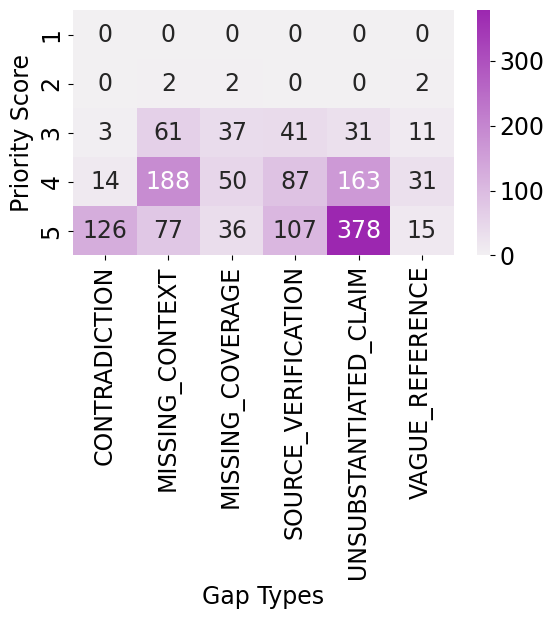

In [6]:
priority_order = [1, 2, 3, 4, 5]

tmp_df = df.copy()
heatmap_data = (
    tmp_df
    .groupby(["gap_types", "p_scores"])
    .size()
    .reset_index(name="count")
    .pivot(index="p_scores", columns="gap_types", values="count")
    .reindex(priority_order)
    .fillna(0)
)

plt.figure(figsize=(6, 6.5))
plt.rcParams["font.size"] = 17

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt="g",
    cmap=sns.light_palette("#9C27B0", as_cmap=True)
)

plt.xlabel("Gap Types")
plt.ylabel("Priority Score")

plt.tight_layout()
plt.savefig("Graphs/GTvsPS.pdf", bbox_inches='tight')

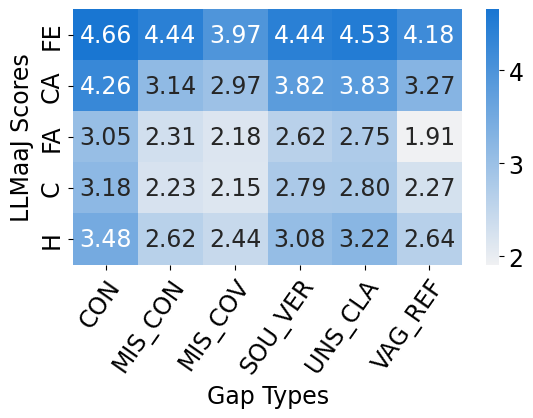

In [39]:
score_order = ["FE", "CA", "FA", "C", "H"]

tmp_df = df.copy()
tmp_df.drop_duplicates(subset=["tid"], inplace=True, keep="first")
heatmap_df = (
    tmp_df.groupby("gap_types")[score_order]
      .mean()
      .T
)

plt.figure(figsize=(6, 4.5))
plt.rcParams["font.size"] = 17

sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".2f",
    # cmap="viridis"
    cmap=sns.light_palette("#1976D2", as_cmap=True)
)

plt.xlabel("Gap Types")
plt.ylabel("LLMaaJ Scores")
plt.xticks(ticks=[0.5,1.5,2.5,3.5,4.5,5.5], labels=["CON", "MIS_CON", "MIS_COV", "SOU_VER", "UNS_CLA", "VAG_REF"], rotation=55, ha="right", rotation_mode="anchor")
plt.tight_layout()
plt.savefig("Graphs/GTvsS.pdf", bbox_inches='tight')

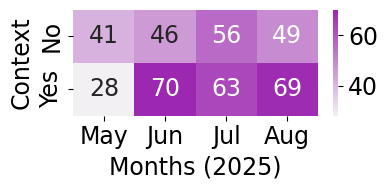

In [ ]:
month_order = ["May", "Jun", "Jul", "Aug"]
context_order = ["No", "Yes"]

tmp_df = df.copy()
tmp_df.drop_duplicates(subset=["tid"], inplace=True, keep="first")
heatmap_data = (
    tmp_df
    .groupby(["tw_date", "is_context"])
    .size()
    .reset_index(name="count")
    .pivot(index="is_context", columns="tw_date", values="count")
    .reindex(index=context_order, columns=month_order)
    .fillna(0)
)

plt.figure(figsize=(4.2, 2.2))
plt.rcParams["font.size"] = 17

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt="g",
    cmap=sns.light_palette("#9C27B0", as_cmap=True)    
)

plt.xlabel("Months (2025)")
plt.ylabel("Context")
plt.tight_layout()
plt.savefig("Graphs/TvsC.pdf", bbox_inches='tight')

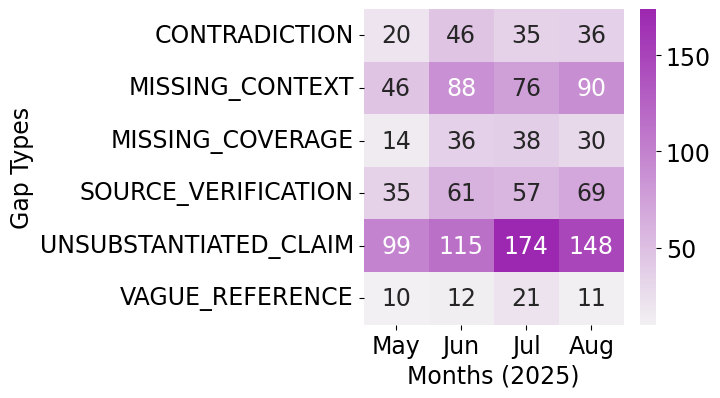

In [ ]:
month_order = ["May", "Jun", "Jul", "Aug"]

tmp_df = df.copy()
heatmap_data = (
    tmp_df
    .groupby(["gap_types", "tw_date"])
    .size()
    .reset_index(name="count")
    .pivot(index="gap_types", columns="tw_date", values="count")
    .reindex(columns=month_order)
    .fillna(0)
)

plt.figure(figsize=(7.3, 4.3))
plt.rcParams["font.size"] = 17

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt="g",
    cmap=sns.light_palette("#9C27B0", as_cmap=True)
)

plt.xlabel("Months (2025)")
plt.ylabel("Gap Types")
plt.tight_layout()
plt.savefig("Graphs/TvsGT.pdf", bbox_inches='tight')

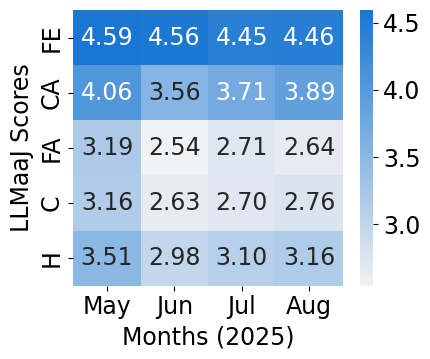

In [ ]:
score_cols = ["FE", "CA", "FA", "C", "H"]

month_order = ["May", "Jun", "Jul", "Aug"]

tmp_df = df.copy()
tmp_df.drop_duplicates(subset=["tid"], inplace=True, keep="first")
heatmap_data = (
    tmp_df
    .groupby("tw_date")[score_cols]
    .mean()
    .reindex(month_order)
    .T
)

plt.figure(figsize=(4.6, 3.9))
plt.rcParams["font.size"] = 17

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap=sns.light_palette("#1976D2", as_cmap=True)
)

plt.xlabel("Months (2025)")
plt.ylabel("LLMaaJ Scores")
plt.tight_layout()
plt.savefig("Graphs/TvsS.pdf", bbox_inches='tight')